# Semi-discrete weight gradients and Laguerre cell masses

This notebook generates `fig:semidiscrete-weight-gradient-cells`.  For a semi-discrete quadratic problem with
$$
    \beta=\sum_{j=1}^m b_j\delta_{y_j},
$$
the dual weights $\gamma_j$ define Laguerre cells
$$
    L_j(\gamma)=\{x:\ \|x-y_j\|^2-\gamma_j\leq \|x-y_k\|^2-\gamma_k\ \text{for all }k\}.
$$
The semi-dual gradient is
$$
    \nabla_{\gamma_j}\mathcal E(\gamma)=b_j-\alpha(L_j(\gamma)).
$$
The figure isolates one target atom and shows how the sign of this gradient changes the geometry: an underweight cell expands, a balanced cell stays put, and an overweight cell shrinks.


In [1]:
from pathlib import Path
import os
import shutil
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

ROOT = Path.cwd()
if (ROOT / "notebooks-figures" / "figure_style.py").exists():
    FIGROOT = ROOT / "notebooks-figures"
elif (ROOT / "figure_style.py").exists():
    FIGROOT = ROOT
    ROOT = FIGROOT.parent
elif (ROOT.parent / "notebooks-figures" / "figure_style.py").exists():
    ROOT = ROOT.parent
    FIGROOT = ROOT / "notebooks-figures"
else:
    raise RuntimeError("Could not locate figure_style.py")

sys.path.insert(0, str(FIGROOT.resolve()))

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image as DisplayImage
from IPython.display import display
from matplotlib.colors import ListedColormap, to_rgb
from matplotlib.patches import FancyArrowPatch

from figure_style import (
    BACKGROUND,
    BLUE,
    DIRAC_MARKER_SIZE,
    RED,
    VIOLET,
    figure_dir,
    interp_color,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

NAME = "semidiscrete-weight-gradient-cells"
OUT = figure_dir(NAME)
ARXIV_OUT = ROOT / "arxiv" / "figures"
THUMB_OUT = FIGROOT / "thumbnails"
ARXIV_OUT.mkdir(parents=True, exist_ok=True)
THUMB_OUT.mkdir(parents=True, exist_ok=True)


## Source density, sites, and balanced weights

The source is a single anisotropic Gaussian density.  The target sites are fixed in all panels and the prescribed masses are uniform.  We first compute nearly balanced weights by a deterministic grid ascent on the semi-dual, then perturb only the highlighted central weight.


In [2]:
xlim = (-2.35, 2.35)
ylim = (-1.75, 1.75)
gx = np.linspace(*xlim, 420)
gy = np.linspace(*ylim, 330)
GX, GY = np.meshgrid(gx, gy)
grid = np.stack([GX, GY], axis=-1)

mean = np.array([0.18, -0.03])
cov = np.array([[0.82, 0.20], [0.20, 0.50]])
inv_cov = np.linalg.inv(cov)
diff = grid - mean
quad = np.einsum("...i,ij,...j->...", diff, inv_cov, diff)
rho = np.exp(-0.5 * quad) / (2 * np.pi * np.sqrt(np.linalg.det(cov)))
rho /= rho.sum()

# The central site is the one whose weight is perturbed in the three panels.
sites = np.array([
    [0.00, 0.00],
    [-0.86, 0.04], [0.86, 0.05],
    [-0.40, 0.78], [0.45, 0.80],
    [-0.47, -0.72], [0.52, -0.72],
    [-1.55, 0.80], [-1.58, -0.74],
    [1.52, 0.78], [1.55, -0.75],
    [0.02, 1.34], [0.05, -1.30],
], dtype=float)

m = len(sites)
focus = 0
beta = np.full(m, 1.0 / m)
C_grid = (grid[..., None, 0] - sites[:, 0]) ** 2 + (grid[..., None, 1] - sites[:, 1]) ** 2


def laguerre_labels(gamma):
    return np.argmin(C_grid - gamma[None, None, :], axis=2)


def cell_masses(labels):
    return np.array([(rho * (labels == j)).sum() for j in range(m)])


gamma_star = np.zeros(m)
for it in range(650):
    labels = laguerre_labels(gamma_star)
    masses = cell_masses(labels)
    step = 1.35 / np.sqrt(it + 8.0)
    gamma_star += step * (beta - masses)
    gamma_star -= gamma_star.mean()

balanced_labels = laguerre_labels(gamma_star)
balanced_masses = cell_masses(balanced_labels)
print(f"balanced L1 mass error = {np.sum(np.abs(balanced_masses - beta)):.3e}")
print(f"highlighted balanced mass = {balanced_masses[focus]:.4f}; target = {beta[focus]:.4f}")


balanced L1 mass error = 1.029e-02
highlighted balanced mass = 0.0770; target = 0.0769


## Three weight states

The panels use the same sites and the same density.  Only the highlighted weight is changed.  Because larger $\gamma_j$ lowers the effective power distance $\|x-y_j\|^2-\gamma_j$, increasing the weight expands the cell, while decreasing it shrinks the cell.  A faint dashed contour marks the balanced cell in the perturbed panels, so the arrows can be read as the local boundary motion caused by the next semi-dual ascent step.


In [3]:
panel_specs = [
    ("underweight", -0.20, "out"),
    ("balanced", 0.00, "none"),
    ("overweight", 0.45, "in"),
]

palette = []
for j, site in enumerate(sites):
    if j == focus:
        palette.append(to_rgb(VIOLET))
    else:
        t = (site[0] - xlim[0]) / (xlim[1] - xlim[0])
        palette.append(interp_color(t, "#dbe5ef", "#8bb9e8"))
cell_cmap = ListedColormap(palette)
density_levels = np.quantile(rho[rho > 0], [0.70, 0.80, 0.88, 0.94, 0.975])


def state_from_delta(delta):
    gamma = gamma_star.copy()
    gamma[focus] += delta
    gamma -= gamma.mean()
    labels = laguerre_labels(gamma)
    masses = cell_masses(labels)
    return gamma, labels, masses


def boundary_radius(gamma, direction, *, rmax=2.10, n=480):
    """Radius where the highlighted continuous Laguerre cell exits a ray."""
    center = sites[focus]
    radii = np.linspace(0.0, rmax, n)
    pts = center[None, :] + radii[:, None] * direction[None, :]
    values = ((pts[:, None, :] - sites[None, :, :]) ** 2).sum(axis=2) - gamma[None, :]
    lab = np.argmin(values, axis=1)
    outside = np.flatnonzero(lab != focus)
    if len(outside) == 0:
        return rmax
    k = int(outside[0])
    return float(radii[max(k - 1, 0)])


def add_weight_arrows(ax, gamma, kind):
    if kind == "none":
        return
    center = sites[focus]
    directions = np.array([
        [1.0, 0.0], [-1.0, 0.0], [0.0, 1.0], [0.0, -1.0],
    ])
    directions = directions / np.linalg.norm(directions, axis=1, keepdims=True)
    for direction in directions:
        r_current = boundary_radius(gamma, direction)
        r_balanced = boundary_radius(gamma_star, direction)
        if kind == "out":
            # Draw the expansion direction in the annulus between current and balanced cells.
            r0 = max(1.05 * r_current, 0.42 * r_balanced)
            r1 = 0.90 * r_balanced
            if r1 <= r0 + 0.045:
                r1 = r0 + 0.13
        else:
            r0 = min(0.94 * r_current, r_balanced + 0.35)
            r1 = max(1.06 * r_balanced, r0 - 0.25)
            if r0 <= r1 + 0.045:
                r0 = r1 + 0.13
        start = center + r0 * direction
        end = center + r1 * direction
        arrow = FancyArrowPatch(
            start,
            end,
            arrowstyle="-|>",
            mutation_scale=6.1,
            lw=0.74,
            color=VIOLET,
            alpha=0.82,
            zorder=9,
        )
        ax.add_patch(arrow)


def draw_state(ax, gamma, labels, arrow_kind):
    ax.set_facecolor(BACKGROUND)
    ax.pcolormesh(GX, GY, labels, cmap=cell_cmap, shading="nearest", alpha=0.31, rasterized=True, zorder=1)
    ax.contour(GX, GY, labels, levels=np.arange(m + 1) - 0.5, colors="white", linewidths=0.50, alpha=0.86, zorder=2)
    if arrow_kind != "none":
        ax.contour(
            GX,
            GY,
            balanced_labels == focus,
            levels=[0.5],
            colors=[VIOLET],
            linewidths=0.58,
            linestyles=":",
            alpha=0.62,
            zorder=4,
        )
    ax.contour(GX, GY, labels == focus, levels=[0.5], colors=[VIOLET], linewidths=1.12, alpha=0.96, zorder=5)
    ax.contour(GX, GY, rho, levels=density_levels, colors=[RED], linewidths=0.58, alpha=0.47, zorder=4)
    ax.scatter(sites[:, 0], sites[:, 1], s=DIRAC_MARKER_SIZE * 0.50, color=BLUE, edgecolor="white", linewidth=0.25, zorder=6)
    ax.scatter(sites[focus, 0], sites[focus, 1], s=DIRAC_MARKER_SIZE * 0.88, color=VIOLET, edgecolor="white", linewidth=0.35, zorder=7)
    add_weight_arrows(ax, gamma, arrow_kind)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal")
    remove_axes(ax)


reported_masses = {}
for name, delta, arrow_kind in panel_specs:
    gamma, labels, masses = state_from_delta(delta)
    reported_masses[name] = masses[focus]
    fig, ax = plt.subplots(figsize=(2.18, 1.82))
    draw_state(ax, gamma, labels, arrow_kind)
    save_pdf(fig, OUT / f"{name}.pdf", pad_inches=0.020)
    plt.close(fig)
    shutil.copyfile(OUT / f"{name}.pdf", ARXIV_OUT / f"{NAME}--{name}.pdf")

fig, axes = plt.subplots(1, 3, figsize=(6.60, 1.86))
for ax, (name, delta, arrow_kind) in zip(axes, panel_specs):
    gamma, labels, _ = state_from_delta(delta)
    draw_state(ax, gamma, labels, arrow_kind)
fig.subplots_adjust(left=0.005, right=0.995, bottom=0.01, top=0.99, wspace=0.035)
fig.savefig(THUMB_OUT / f"{NAME}.png", dpi=210, bbox_inches="tight", pad_inches=0.025)
plt.close(fig)

for name, mass in reported_masses.items():
    gradient = beta[focus] - mass
    print(f"{name:>11s}: highlighted mass = {mass:.4f}, target = {beta[focus]:.4f}, gradient = {gradient:+.4f}")
print(f"Wrote {OUT}")
print(f"Wrote {THUMB_OUT / (NAME + '.png')}")


underweight: highlighted mass = 0.0285, target = 0.0769, gradient = +0.0484
   balanced: highlighted mass = 0.0770, target = 0.0769, gradient = -0.0001
 overweight: highlighted mass = 0.2447, target = 0.0769, gradient = -0.1678
Wrote /Users/gpeyre/Dropbox/github/ot4ml/latex/figures/semidiscrete-weight-gradient-cells
Wrote /Users/gpeyre/Dropbox/github/ot4ml/notebooks-figures/thumbnails/semidiscrete-weight-gradient-cells.png


## Gallery preview

The PDFs are title-free; panel labels are added in LaTeX.  The PNG below is the compact gallery thumbnail regenerated from the same drawing code.


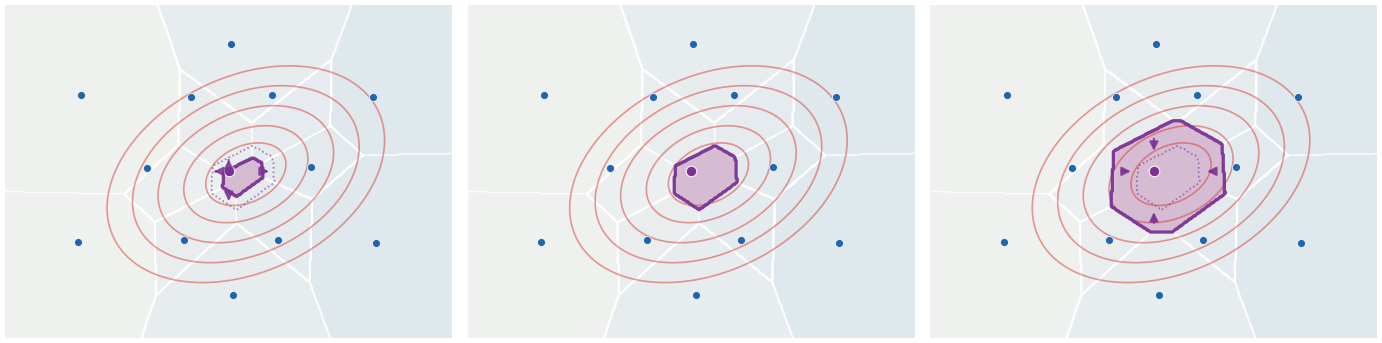

In [4]:
display(DisplayImage(filename=str(THUMB_OUT / f"{NAME}.png"), width=720))
